In [1]:
!pip install transformers datasets scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [3]:
train = pd.read_csv("https://raw.githubusercontent.com/HarshAggarwal524/hinglish-sentiment-analysis/main/data/emotion_train_final.csv")
dev = pd.read_csv("https://raw.githubusercontent.com/HarshAggarwal524/hinglish-sentiment-analysis/main/data/emotion_dev_final.csv")

label2id = {'anger': 0, 'joy': 1, 'sadness': 2, 'trust': 3}
id2label = {0: 'anger', 1: 'joy', 2: 'sadness', 3: 'trust'}

train['label'] = train['emotion'].map(label2id)
dev['label'] = dev['emotion'].map(label2id)

print("Train:", train.shape)
print("Dev:", dev.shape)

Train: (5083, 4)
Dev: (897, 4)


In [4]:
muril_tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

dev_dataset = EmotionDataset(dev, muril_tokenizer)
print("Dev dataset ready:", len(dev_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Dev dataset ready: 897


In [6]:
class_weights = torch.tensor([1.0, 1.2, 5.5, 8.0]).to('cuda')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        from torch.nn import CrossEntropyLoss
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {'macro_f1': f1_macro}

def train_muril_on_subset(train_df, subset_size, dev_dataset):
    # Stratified sample of subset_size from train
    subset = train_df.groupby('emotion', group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(subset_size * len(x) / len(train_df))),
                           random_state=42)
    ).reset_index(drop=True)

    print(f"\nTraining on {len(subset)} tweets")
    print(subset['emotion'].value_counts())

    train_dataset = EmotionDataset(subset, muril_tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        "google/muril-base-cased",
        num_labels=4,
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=f"./muril_ablation_{subset_size}",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",  # don't save checkpoints to save disk space
        logging_steps=50,
        fp16=True
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    return results['eval_macro_f1']

In [7]:
# Subset sizes to test
sizes = [500, 1000, 2000, 5083]
f1_scores = []

for size in sizes:
    if size == 5083:
        # Full dataset — use result we already have
        f1_scores.append(0.611)
        print(f"\nSize {size}: F1=0.611 (from previous run)")
    else:
        f1 = train_muril_on_subset(train, size, dev_dataset)
        f1_scores.append(f1)
        print(f"\nSize {size}: F1={f1:.3f}")

print("\nFinal ablation results:")
for size, f1 in zip(sizes, f1_scores):
    print(f"  {size} tweets: {f1:.3f}")


/tmp/ipykernel_4494/2668546782.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset = train_df.groupby('emotion', group_keys=False).apply(



Training on 498 tweets
emotion
anger      233
joy        195
sadness     42
trust       28
Name: count, dtype: int64


pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Epoch,Training Loss,Validation Loss,Macro F1
1,1.383456,1.361557,0.375286
2,1.284657,1.269387,0.396009
3,1.228399,1.220623,0.460873
4,1.155316,1.190846,0.425448
5,1.116736,1.184216,0.418241


Training Loss,Validation Loss,Epoch,Macro F1
1.116736,1.184216,5,0.418241



Size 2000: F1=0.418

Size 5083: F1=0.611 (from previous run)

Final ablation results:
  500 tweets: 0.392
  1000 tweets: 0.412
  2000 tweets: 0.418
  5083 tweets: 0.611


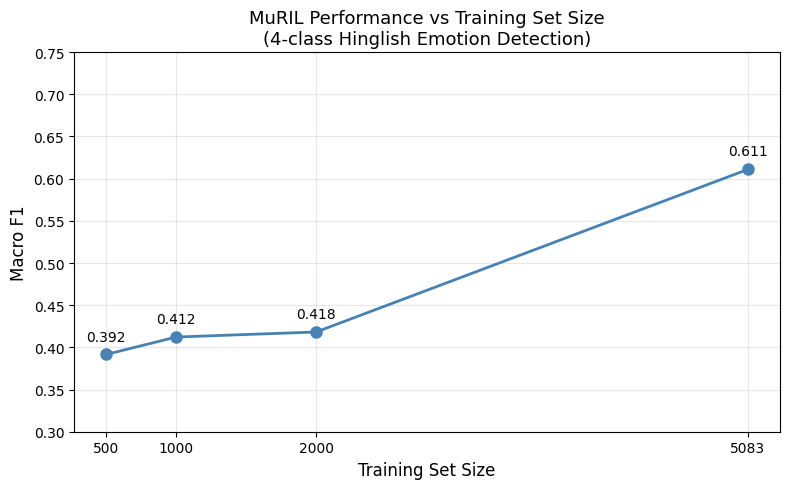

✓ Figure saved as muril_ablation_curve.png


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(sizes, f1_scores, marker='o', linewidth=2, markersize=8, color='steelblue')

# Annotate each point
for size, f1 in zip(sizes, f1_scores):
    plt.annotate(f'{f1:.3f}', (size, f1), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10)

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Macro F1', fontsize=12)
plt.title('MuRIL Performance vs Training Set Size\n(4-class Hinglish Emotion Detection)', fontsize=13)
plt.xticks(sizes, [str(s) for s in sizes])
plt.ylim(0.3, 0.75)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('muril_ablation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved as muril_ablation_curve.png")